<center>
<img src="images/t_shirts.jpg" width=100 height =100>
</center>

<h2 style="text-align:center; color:blue";> Lab4 -Classifying Images of Clothing  </h2>
<h3 style="text-align:center; color:blue";> Multilayer Classification of Fashion MNIST Dataset</h3>
<center>
<h3>by Joshua Brewington</h3>

## Fashion MNIST classification with SciKit-Learn using MLPClassifier

This notebook shows how to define and train a simple Neural-Network for image classification using SciKit-Learn's MLPClasifier.

## Learning Objectives
* Import and learn about the Fashion MNIST dataset and its structure
* Create training , validation and test datasets from the Fashion MNISTt dataset
* Build a simple but effective Scikit Learn MLPClassifier model for articles of clothing based on looking at every pixel in the image
* Test the model's performance in the real-world on images from online clothing catalogs



**Note**: If you are running this in [a colab notebook](http://jmu.edu), we recommend you enable a free GPU by going:

> **Runtime**   →   **Change runtime type**   →   **Hardware Accelerator: GPU**

If you are running in colab, you should install the dependencies and download the dataset by running the following cell:

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

This lab uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="images/fashion_mnist.png" width=500;
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>


Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from fetch_openml. Import and load the Fashion MNIST data:

## Load the Fashion MNIST Dataset
Using SciKit-Learns ```fetch_openml``` to load fashion_mnist data.

In [2]:
# Load data from https://www.openml.org/
fashion_mnist=fetch_openml(name="Fashion-MNIST")

### Print the Shape of the data

In [3]:
fashion_mnist.data.shape

(70000, 784)

There are 70,000 images and each image has 784 features (each image is 28 x 28 pixels and each pixel represents a feature of an image )

## Preprocessing Data

Each image of the fashion_mnist dataset is encoded in a 784 dimensional vector, representing a 28 x 28 pixel image. Each pixel has a value between 0 and 255, representing the pixels intensity, from 0 (white) to 255 (black) corresponding to the grey-value of a pixel.<br />
The above ```fetch_openml``` method to load fashion mnist returns ```data``` and ```target``` as ```uint8``` which we convert to ```float32``` and ```int64``` respectively.

In [4]:
X = fashion_mnist.data.astype('float32')
y = fashion_mnist.target.astype('int64')

#### Train/Test Split
The fashion_mnist data is *already split* into a training set (the first 60,000 images) and a test set (the last 10,000 images).  Furthermore, the training set is already shuffled for us! So we can just use python list slicing to generate our datasets from the full set of images.

In [5]:
train_images, test_images, train_labels, test_labels = X[:60000], X[60000:], y[:60000], y[60000:]

#### Print shapes of training and testing sets

In [6]:
train_images.shape, train_labels.shape

((60000, 784), (60000,))

Loading the dataset returns four NumPy arrays:

* The `train_images` and `train_labels` arrays are the *training set*—the data the model uses to learn.
* The model is tested against the *test set*, the `test_images`, and `test_labels` arrays.

The images are 28x28 NumPy arrays, with pixel values ranging from 0 to 255. The *labels* are an array of integers, ranging from 0 to 9. These correspond to the *class* of clothing the image represents:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [7]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Preprocess the data

The data must be preprocessed before training the network. If you inspect the first image in the training set, you will see that the pixel values fall in the range of 0 to 255:

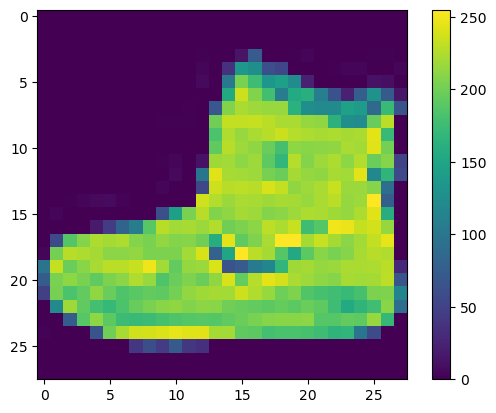

In [8]:
plt.figure()
plt.imshow(train_images[0:1].values.reshape(28,28))
plt.colorbar()
plt.grid(False)
plt.show()

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the *training set* and the *testing set* be preprocessed in the same way:

In [9]:
train_images = train_images / 255.0

test_images = test_images / 255.0

To verify that the data is in the correct format and that you're ready to build and train the network, let's display the first 25 images from the *training set* and display the class name below each image.

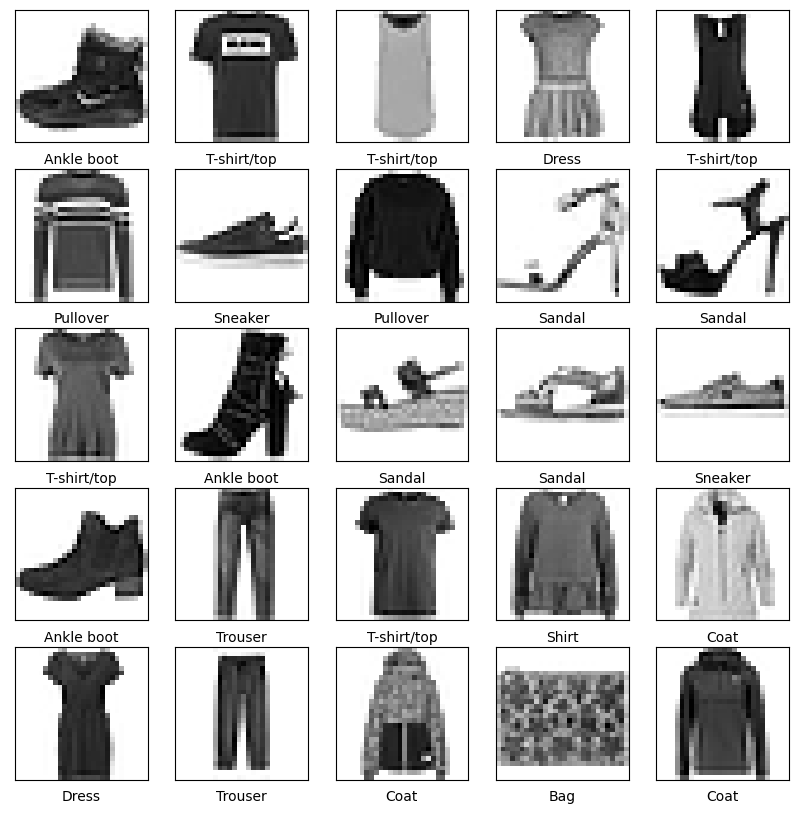

In [10]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i:i+1].values.reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

### Is the Training Dataset Balanced?
Let's plot a histogram of the training dastset labels class labels to make sure we have a balanaced dataset, i.e.we want to figure out how often each number is represented in the training dataset This is important when we are trying to eliminate **algorithmic bias** in our machine learning models.

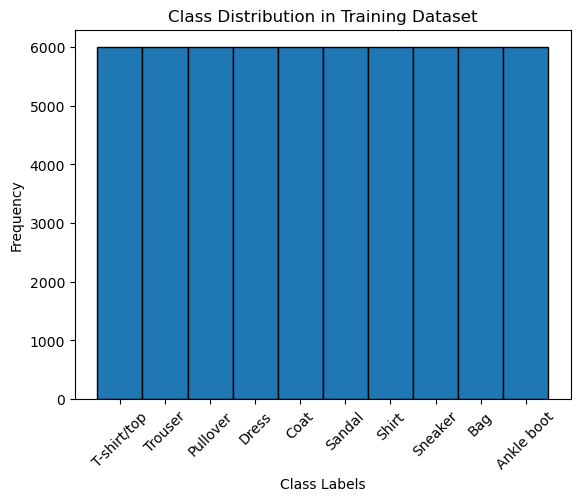

In [11]:
unique_labels, label_counts = np.unique(train_labels, return_counts=True)

# Create a bar plot (histogram) of the class distribution
plt.bar(class_names, label_counts,width=1,edgecolor='black')

# Add labels and title
plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.title('Class Distribution in Training Dataset')

# Rotate the x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Show the plot
plt.show()


We see the number of examples for each piece of clothing to detect is appears to be *evenly distributed*. So the dataset is balanced.

## Build the model

Building the neural network requires configuring the layers of the model, then compiling the model.

### Build Neural Network with Scikit Learn MultiLayer Perceptron Classifier
**Build the model with 3 hidden layers as follows:**
- hidden layer = 128 neurons
- hidden layer = 64 neurons
- hidden layer = 32 neurons
 
**also, use these parameters**
- solver ='adam'
- learning_rate_init= 0.001
- tol=1e-2
- max_iter= 500
- verbose = True
- random_state=1

You can use the default values for the rest of the parameters

MLP trains on two arrays: array X of size (n_samples, n_features), which holds the training samples represented as floating point feature vectors; and array y of size (n_samples,), which holds the target values (class labels) for the training samples:

In [12]:
#YOUR CODE HERE

from sklearn.neural_network import MLPClassifier

mlp_fashion_mnist_model = MLPClassifier(solver='adam',hidden_layer_sizes=(128,64,32)
                                       ,learning_rate_init=0.001,random_state=1,max_iter=500,verbose=True,tol=1.0e-2)

mlp_fashion_mnist_model.fit(train_images,train_labels)

Iteration 1, loss = 0.61635824
Iteration 2, loss = 0.41334649
Iteration 3, loss = 0.36546846
Iteration 4, loss = 0.34242380
Iteration 5, loss = 0.31960061
Iteration 6, loss = 0.30859242
Iteration 7, loss = 0.29069861
Iteration 8, loss = 0.28148208
Iteration 9, loss = 0.27315184
Iteration 10, loss = 0.26216654
Iteration 11, loss = 0.25528226
Iteration 12, loss = 0.25148457
Iteration 13, loss = 0.23907153
Iteration 14, loss = 0.23149976
Iteration 15, loss = 0.22406476
Iteration 16, loss = 0.22171399
Iteration 17, loss = 0.21517663
Iteration 18, loss = 0.20930160
Iteration 19, loss = 0.20328245
Iteration 20, loss = 0.20074478
Iteration 21, loss = 0.19376169
Iteration 22, loss = 0.19121589
Iteration 23, loss = 0.19055008
Iteration 24, loss = 0.17857131
Iteration 25, loss = 0.17617366
Iteration 26, loss = 0.17466620
Iteration 27, loss = 0.17136260
Iteration 28, loss = 0.16275971
Iteration 29, loss = 0.16215279
Iteration 30, loss = 0.15746613
Iteration 31, loss = 0.15420687
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=1,
              tol=0.01, verbose=True)

In [13]:
mlp_fashion_mnist_model.out_activation_

'softmax'

In [14]:
mlp_fashion_mnist_model.n_layers_

5

In [15]:
mlp_fashion_mnist_model.n_outputs_

10

In [16]:
mlp_fashion_mnist_model.n_iter_

35

### Model Evaluation and Performance

In [17]:
#YOUR CODE HERE

mlp_fashion_mnist_model.score(test_images,test_labels)

0.8912

An accuracy of about <font color='red'>89.67% </font>for a network with only <font color='red'>3 </font> hidden layers is not too bad.
 
Let's take a look at some predictions that **went wrong**:

In [18]:
#from sklearn.metrics import accuracy_score
y_pred = mlp_fashion_mnist_model.predict(test_images)
#accuracy_score(test_labels,y_pred)

In [19]:
error_mask = y_pred != test_labels

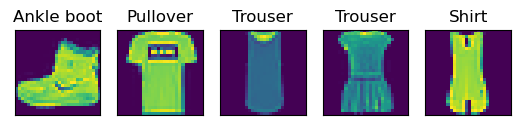

In [20]:
def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    for i, (img, y) in enumerate(zip(X[:5].values.reshape(5, 28, 28), y[:5])):
        plt.subplot(1, 5, 1 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(class_names[y])
    plt.show()
    
plot_example(train_images,test_labels)

### Plot some misclassified images

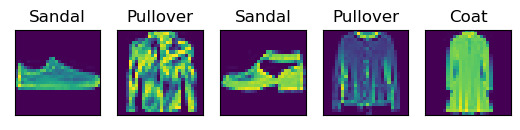

In [21]:

plot_example(test_images[error_mask], y_pred[error_mask])

### Plot the loss curve

In [22]:
loss_values = mlp_fashion_mnist_model.loss_curve_

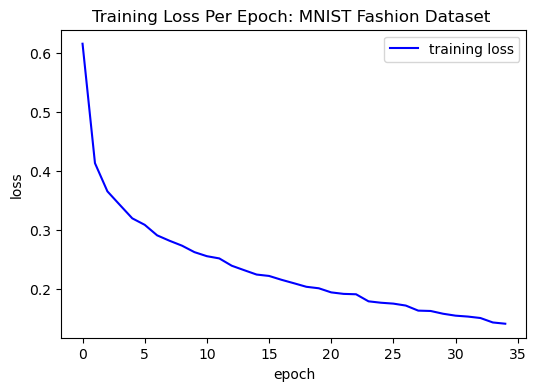

In [23]:
#YOUR CODE HERE

fig = plt.figure(figsize=(6, 4))
plt.plot(loss_values, color="blue", label = 'training loss')
plt.xlabel('epoch')
plt.ylabel('loss');
#legend
plt.legend(loc='upper right')
#title
plt.title('Training Loss Per Epoch: MNIST Fashion Dataset ')
#show plot
plt.show()

 #### Confusion Matrix
 A further statistic is the confusion matrix that shows the errors that the classifier made during training..

In [24]:
from sklearn import metrics
print ("Classification Report:")
print (metrics.classification_report(test_labels, y_pred))
print ("Confusion Matrix:")
print (metrics.confusion_matrix(test_labels, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1000
           1       0.98      0.98      0.98      1000
           2       0.80      0.82      0.81      1000
           3       0.89      0.90      0.90      1000
           4       0.81      0.85      0.83      1000
           5       0.96      0.98      0.97      1000
           6       0.71      0.71      0.71      1000
           7       0.93      0.96      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.98      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Confusion Matrix:
[[806   1  18  22   6   1 138   1   7   0]
 [  2 976   3  13   2   0   3   0   1   0]
 [ 13   1 823   9  89   0  65   0   0   0]
 [ 13  13  11 897  23   1  38   0   4   0]
 [  0   0  76  33 850   0  4

# <font color=red>  Exercises </font> 

<h4 style="text-align:left; color:green";> Answer the questions below in your notebook. Submit your completed Jupyter Notebook  and <b>zip</b> it along with any other files or subfolders contiainng your images, etc.</h4>

### Exercise 1 (5 points)
  - Based on the confusion matrix, which article of clothing was hardest for the model to classify? Justify your answer!. 
  
The hardest one for the model to classify was class label 6, or shirts. This is because class label 6 has the lowest recall score and the math checks out with the confusion matrix. If you take the predicted correctly number (712) from the diagonal associated with class label 6 and divide it over the sum of all the values in that row, it gives you the recall score. 712/1000 = 0.71.

### Exercise 2 (5 points)
- Based on the output of your **classification report**, out of all the times `the dress` should have been predicted, what percentage of times was it correctly predicted? 
(HINT: You may need to research the meaning and difference between precision, recall and f1-score)

 - Do a simple calculation (do it here!) to justify your answer. It compares to what metric in the classification report?
 
For Dress:

Precision: 0.89
Recall: 0.90
F1-Score:0.90

Percentage Correctly Predicted = Recall * 100

Percentage Correctly Predicted = 0.90 * 100 = 90%

It compares the most to recall because it is used in the formula for accuracy.

### Exercise 3 (5 points)

- Using *minimum code snippets from above*, train the model using the 'sgd' optimizer (scikit learn calls it a *solver*).  Does the accuracy improve (print it below)? Comment (one line!) as to what you think is contributing to the change in performance of the model. **Be careful not to overwrite your previous model's values that you just trained, i.e., use different naming(s) for this model.**  *Do not use this model after this exercise*

In [25]:
#YOUR CODE HERE

mp_fashion_mnist_model = MLPClassifier(solver='sgd',hidden_layer_sizes=(128,64,32)
                                       ,learning_rate_init=0.001,random_state=1,max_iter=500,verbose=True,tol=1.0e-2)

mp_fashion_mnist_model.fit(train_images,train_labels)

Iteration 1, loss = 1.50646588
Iteration 2, loss = 0.76844106
Iteration 3, loss = 0.63604859
Iteration 4, loss = 0.57059351
Iteration 5, loss = 0.53219053
Iteration 6, loss = 0.50702550
Iteration 7, loss = 0.48839067
Iteration 8, loss = 0.47289267
Iteration 9, loss = 0.46116773
Iteration 10, loss = 0.45039272
Iteration 11, loss = 0.44041953
Iteration 12, loss = 0.43238067
Iteration 13, loss = 0.42482671
Iteration 14, loss = 0.41804513
Iteration 15, loss = 0.41132351
Iteration 16, loss = 0.40618826
Iteration 17, loss = 0.40018308
Iteration 18, loss = 0.39551181
Iteration 19, loss = 0.39003242
Iteration 20, loss = 0.38585168
Iteration 21, loss = 0.38137722
Training loss did not improve more than tol=0.010000 for 10 consecutive epochs. Stopping.


MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=1,
              solver='sgd', tol=0.01, verbose=True)

In [26]:
print(f'The accuracy of the sgd model is {mp_fashion_mnist_model.score(test_images,test_labels)} compared to the adam model accuracy of 0 {mlp_fashion_mnist_model.score(test_images,test_labels)}.')

The accuracy of the sgd model is 0.8529 compared to the adam model accuracy of 0 0.8912.


### Exercise 4 (5 points)
- Feed the model a **single** image from the test set to classify (**feed it the 17th. test set image**) and have the model return the class membership probabilities and print them out for this single image classification. *Note* you have to reshape the imgage to 8 x 8 **before** you try and display it! Use the model that performedthe **best** for this part.

In [27]:
#YOUR CODE HERE

index = 16
predicted_digit = y_pred[index]

prob = mlp_fashion_mnist_model.predict_proba(test_images[16:17])
#print(prob)
print(np.argmax(prob))

2


### Exercise 5 (5 points)
* Print out the image's number **and** the name of the article of clothing in one complete sentence. Your code snippet should be general and the image number should **not** be hard-coded

In [28]:
#print(f'Image Number: {index}')

#unique_labels[index]
predicted_class_name = test_labels[16:17]
#print(f'Predicted Article of Clothing: {predicted_class_name}')

predicted_class_name_series = test_labels[16:17]

# Extract the integer value from the Series
predicted_class_name = predicted_class_name_series.values[0]

def int_to_class(number):
    class_labels = {
        0: 'T-shirt/top',
        1: 'Trouser',
        2: 'Pullover',
        3: 'Dress',
        4: 'Coat',
        5: 'Sandal',
        6: 'Shirt',
        7: 'Sneaker',
        8: 'Bag',
        9: 'Ankle boot'
    }

    if number in class_labels:
        return class_labels[number]
    else:
        return ""
    
print(f'Image Number: {index + 1}, Predicted Article of Clothing: {int_to_class(predicted_class_name)}.')


Image Number: 17, Predicted Article of Clothing: Pullover.


### Exercise 6 (5 points)
Display an image of the clothing item you from Exercise (5)

The corresponding predicted image is:


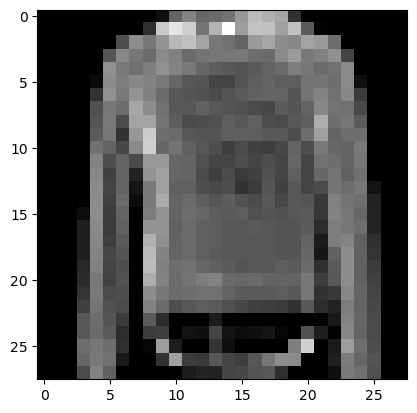

In [29]:
#YOUR CODE HERE

original_image = test_images.iloc[16].values.reshape(28, 28)

# Reshape it into an 8x8 image
#reshaped_image = original_image[:8, :8]

# Display the reshaped image
print('The corresponding predicted image is:')
plt.imshow(original_image, cmap='gray')  # Use cmap='gray' for grayscale images
plt.show()

### <font color=blue>  Exercise 7 (20 points) </font> 
#### Real-World Testing
Get an image of one of the clothing pieces from the web and apply your model to it. How does it perform? To resize, greyscale and invert your image you can try and use the code below where I give only comments (but I think is easiest with research from the web) or one of the websites listed here:

1. [resizeimage.net](https://resizeimage.net/)
2. [pixlr.com](https://pixlr.com/e/)
3. [photopea.com](https://www.photopea.com/)


#### Load, resize and transform  images
  
<font color=blue>Good reference on using Pillow: </font>  [Image Processing in Python with Pillow](https://auth0.com/blog/image-processing-in-python-with-pillow/)

In [30]:
#YOUR CODE HERE

In [34]:
# YOUR CODE BELOW
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

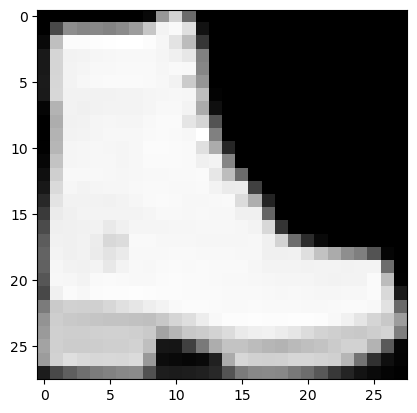

AttributeError: 'function' object has no attribute 'FLIP_LEFT_RIGHT'

In [36]:
from PIL import Image
import PIL.ImageOps
#load the image
image_path = "images/Timberland-6-Inch-Boot-Off-White-Black-Velvet.png.jpg"
image = Image.open(image_path)
#resize the image
image = image.resize((28, 28))
# convert the image to *greyscale*
image = PIL.ImageOps.grayscale(image)

# invert image
image = PIL.ImageOps.invert(image)

#show the image
plt.imshow(image, cmap='gray')
plt.show()

#convert to an numpy array
image_array = np.array(image)
#turn back into a vector of dimensions 784 (= 28*28)

# Flip the image horizontally (left to right)
horizontal_flip = image.transpose.FLIP_LEFT_RIGHT

image_vector = image_array.reshape(784)
# send the image the classsifer for prediction
predicted_class = mlp_fashion_mnist_model.predict([image_vector])

#print the class name of the item of clothing

predicted_class_name = class_names[predicted_class[0]]
print(f"Predicted Article of Clothing: {predicted_class_name}")

#### Display the item of clothing

<center>
<img src="images/Timberland-6-Inch-Boot-Off-White-Black-Velvet.png.jpg" width=100 height =100>

The model incorrectly predicted the article of clothing. The boots in the sample were facing the other direction, which lead to the model incorrectly predicting the boot.

logistic regression, support vectors, K-Nearest Neighbor, MLP model,